# Load libraries

In [6]:
import pandas as pd
import numpy as np

# Load data

In [7]:

df = pd.read_csv("googleplaystore.csv")
df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:
# DATA SUMMARY
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
#sum of number of ratings
df["Rating"].sum()

np.float64(39279.0)

In [7]:
# AVERAGE RATING OF FREE APPS
df[df["Type"] == "Free"]["Rating"].mean()

np.float64(4.186202546163551)

In [8]:
#AVERAGE RATING OF PAID APPS
df[df["Type"] == "Paid"]["Rating"].mean()

np.float64(4.26661514683153)

# DEALING WITH THE NULLS

In [16]:
# COUNT THE NUMBER OF ROWS
len(df)

10841

Seems like we have some null values, specially in rating

In [17]:
df.isna().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
# FILL THE NULL VALUES IN THE DATASET WITH UKNOWN
df.fillna("Unknown", inplace=True)

/var/folders/b7/yg62l3k53kvc1lvmnwswr23m0000gn/T/ipykernel_18485/2627681849.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [10]:
df.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

We opted for this solution since 1474/10841 represents arround 13%, but there are outliers so applying the mean is risky, and the mode might work, but we have more than
9.000 ratings, so it's more than enough to get insights and we want to focus on the most accurate information 

NameError: name 'df' is not defined

In [11]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv")

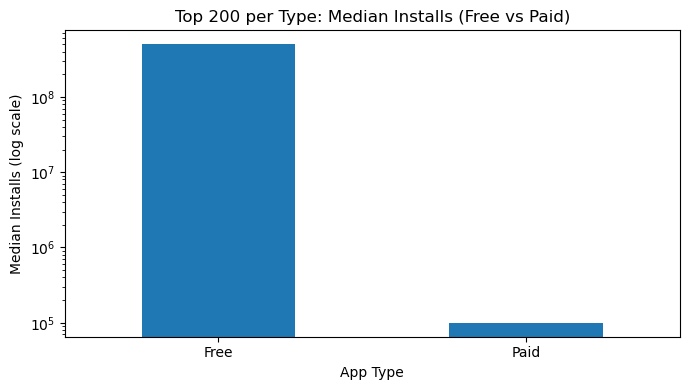

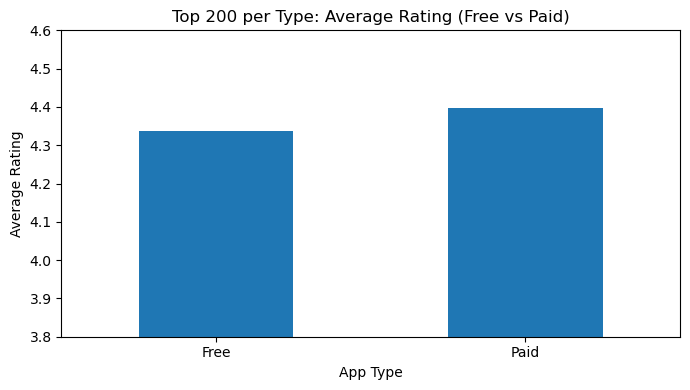

      n_apps  median_installs  mean_rating  median_rating
Type                                                     
Free     200      500000000.0       4.3370           4.35
Paid     200         100000.0       4.3965           4.40


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- If df isn't loaded yet, uncomment this ---
# df = pd.read_csv("googleplaystore.csv")

# -------------------------
# CLEANING (safe)
# -------------------------
df = df.copy()

# Clean installs (turn junk into NaN)
df["Installs_clean"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# Clean ratings (turn junk into NaN)
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep only Free/Paid with valid installs
df_viz = df.dropna(subset=["Type", "Installs_clean"]).copy()
df_viz["Type"] = df_viz["Type"].astype(str).str.strip()
df_viz = df_viz[df_viz["Type"].isin(["Free", "Paid"])]

# -------------------------
# FAIR SAMPLE: Top 200 per Type
# -------------------------
top200_free = df_viz[df_viz["Type"] == "Free"].sort_values("Installs_clean", ascending=False).head(200)
top200_paid = df_viz[df_viz["Type"] == "Paid"].sort_values("Installs_clean", ascending=False).head(200)

top200_by_type = pd.concat([top200_free, top200_paid], ignore_index=True)

# -------------------------
# GRAPH 1: Median installs per app (log scale)
# -------------------------
median_installs = top200_by_type.groupby("Type")["Installs_clean"].median().reindex(["Free", "Paid"])

plt.figure(figsize=(7,4))
(median_installs + 1).plot(kind="bar")
plt.yscale("log")
plt.title("Top 200 per Type: Median Installs (Free vs Paid)")
plt.xlabel("App Type")
plt.ylabel("Median Installs (log scale)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------
# GRAPH 2: Average rating per app (same sample)
# -------------------------
ratings_sample = top200_by_type.dropna(subset=["Rating_clean"]).copy()
avg_ratings = ratings_sample.groupby("Type")["Rating_clean"].mean().reindex(["Free", "Paid"])

plt.figure(figsize=(7,4))
avg_ratings.plot(kind="bar")
plt.title("Top 200 per Type: Average Rating (Free vs Paid)")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(3.8, 4.6)
plt.tight_layout()
plt.show()

# -------------------------
# Print numbers for your conclusion
# -------------------------
summary = pd.DataFrame({
    "n_apps": top200_by_type.groupby("Type")["App"].count(),
    "median_installs": top200_by_type.groupby("Type")["Installs_clean"].median(),
    "mean_rating": ratings_sample.groupby("Type")["Rating_clean"].mean(),
    "median_rating": ratings_sample.groupby("Type")["Rating_clean"].median(),
}).reindex(["Free", "Paid"])

print(summary)

In [ ]:
#Installs chart: Free apps have a much higher typical (median) install count than Paid apps. 
#This graph compares the median number of installs for free and paid apps.
#The median represents the typical number of installs, since it is the middle value when apps are ordered by downloads. Using the median avoids distortion from extremely popular apps. 
#The results show that free apps generally reach many more users than paid apps.

#Ratings chart: Paid apps are not rated worse, and can even be slightly higher.

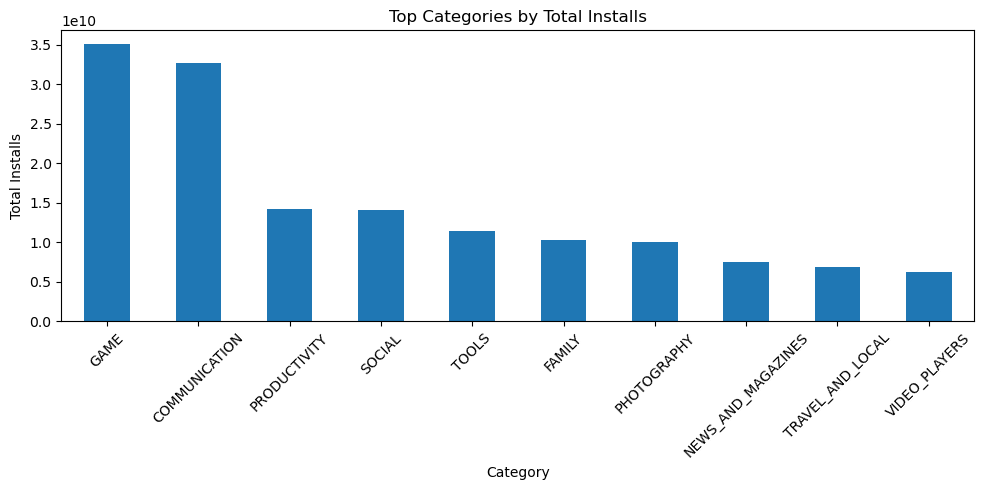

In [16]:
# Total installs by category
installs_by_category = df_viz.groupby("Category")["Installs_clean"].sum()

# Get top 10 categories
top_installs_categories = installs_by_category.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_installs_categories.plot(kind="bar")

plt.title("Top Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

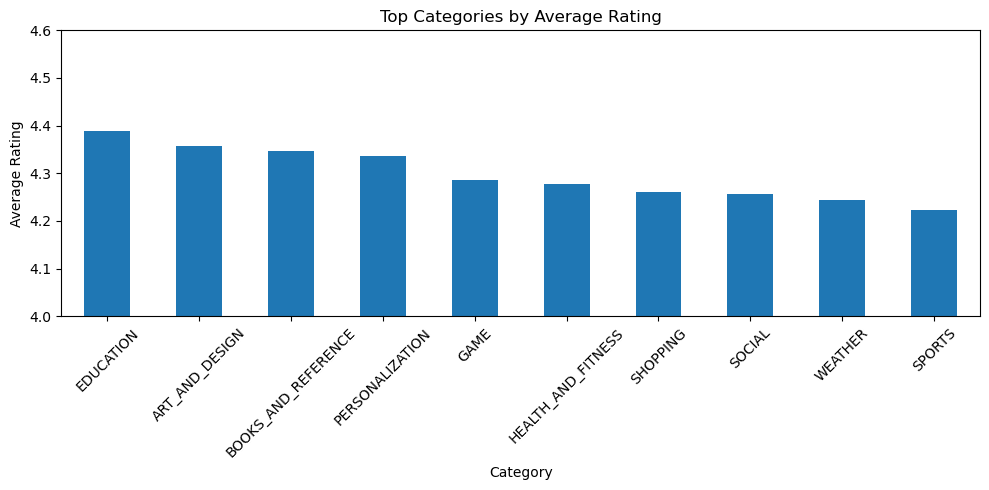

In [20]:
# Count how many apps each category has
category_counts = df_viz.groupby("Category")["Rating_clean"].count()

# Keep only categories with enough apps (at least 50)
valid_categories = category_counts[category_counts > 50].index

# Compute average rating for those categories
ratings_by_category = (
    df_viz[df_viz["Category"].isin(valid_categories)]
    .groupby("Category")["Rating_clean"]
    .mean()
)

# Take the top 10 highest-rated categories
top_ratings_categories = ratings_by_category.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,5))

top_ratings_categories.plot(kind="bar")

plt.title("Top Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")

# Rotate labels for readability
plt.xticks(rotation=45)

# Zoom y-axis so differences are visible
plt.ylim(4.0, 4.6)

plt.tight_layout()
plt.show()

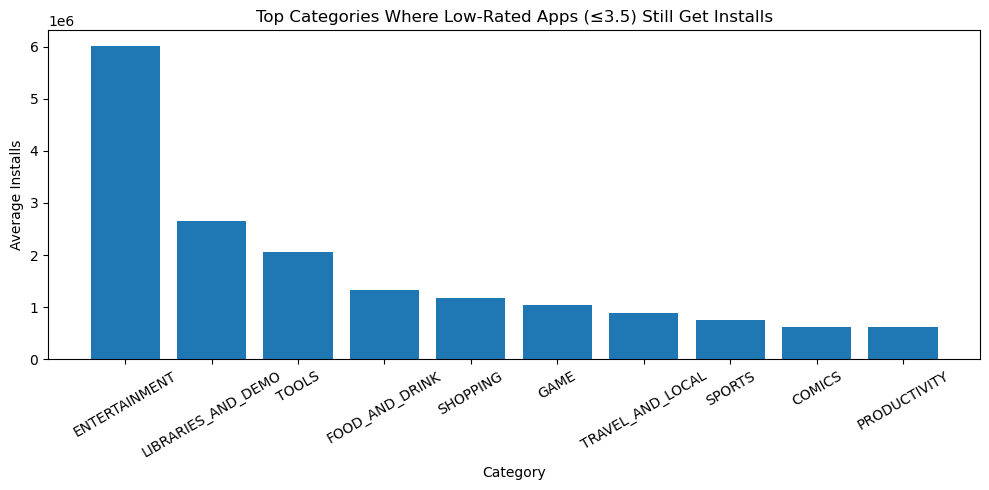

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("googleplaystore.csv")

# Clean installs
df["Installs_clean"] = (
    df["Installs"].astype(str)
    .str.replace("+","", regex=False)
    .str.replace(",","", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# Clean ratings
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep usable rows
df_clean = df.dropna(subset=["Category","Installs_clean","Rating_clean"]).copy()

# Low rated apps
low_rated_apps = df_clean[df_clean["Rating_clean"] <= 3.5]

# Aggregate by category
low_rating_categories = low_rated_apps.groupby("Category").agg(
    avg_installs=("Installs_clean","mean"),
    n_apps=("App","count")
).reset_index()

# Take top 10 by installs
top_categories = low_rating_categories.sort_values(
    "avg_installs", ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,5))

plt.bar(top_categories["Category"], top_categories["avg_installs"])

plt.title("Top Categories Where Low-Rated Apps (≤3.5) Still Get Installs")
plt.xlabel("Category")
plt.ylabel("Average Installs")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Number of apps rated ≤ 3.5: 896


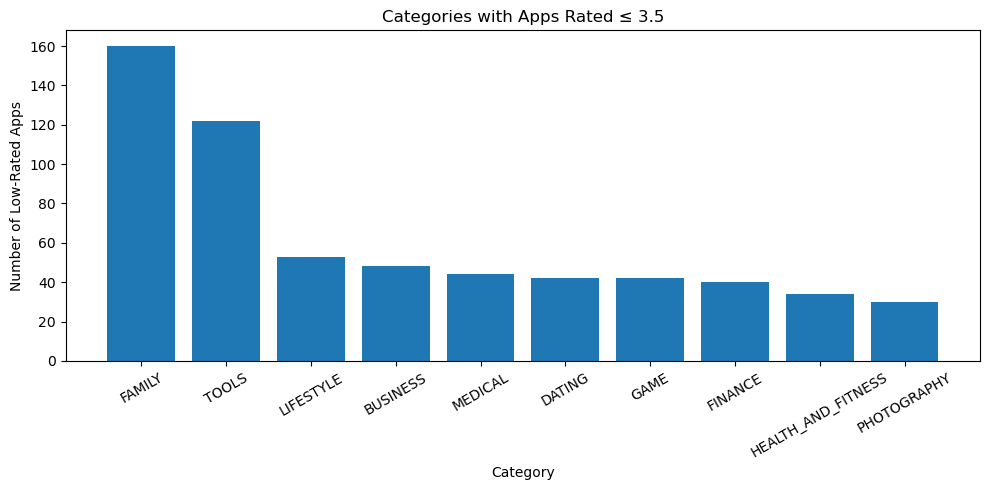

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("googleplaystore.csv")

# Clean installs
df["Installs_clean"] = (
    df["Installs"].astype(str)
    .str.replace("+","", regex=False)
    .str.replace(",","", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# Clean ratings
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep usable rows
df_clean = df.dropna(subset=["Category","Installs_clean","Rating_clean"])

# Select apps rated 3.5 or lower
low_rated_apps = df_clean[df_clean["Rating_clean"] <= 3.5]

print("Number of apps rated ≤ 3.5:", len(low_rated_apps))

# If none exist, stop
if low_rated_apps.empty:
    print("No apps rated 3.5 or below found in the dataset.")
else:

    # Count low-rated apps per category
    category_counts = low_rated_apps.groupby("Category").size().sort_values(ascending=False)

    # Take top 10 categories
    top_categories = category_counts.head(10)

    # Plot
    plt.figure(figsize=(10,5))
    plt.bar(top_categories.index, top_categories.values)

    plt.title("Categories with Apps Rated ≤ 3.5")
    plt.xlabel("Category")
    plt.ylabel("Number of Low-Rated Apps")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

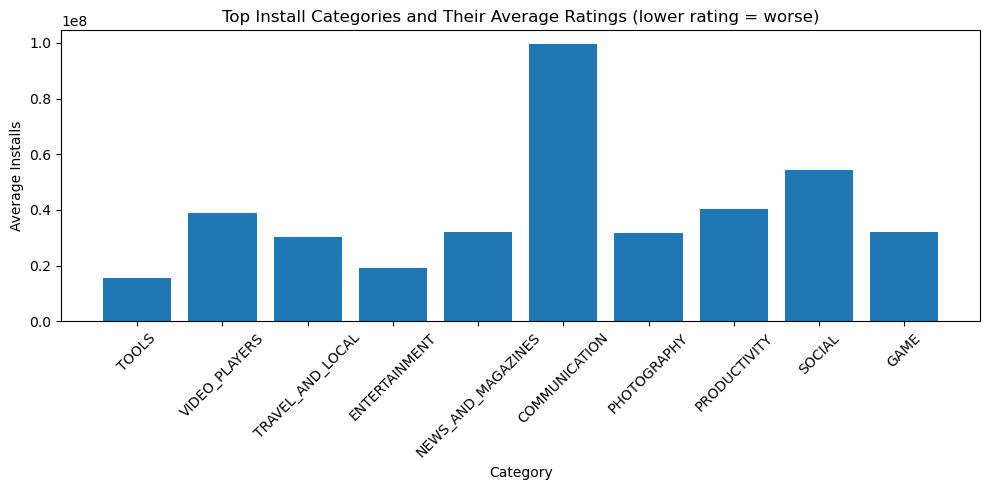

              Category  avg_installs  avg_rating
29               TOOLS  1.560044e+07    4.047411
31       VIDEO_PLAYERS  3.888686e+07    4.063750
30    TRAVEL_AND_LOCAL  3.039318e+07    4.109292
9        ENTERTAINMENT  1.925611e+07    4.126174
21  NEWS_AND_MAGAZINES  3.217258e+07    4.132189
6        COMMUNICATION  9.953427e+07    4.158537
24         PHOTOGRAPHY  3.182411e+07    4.192114
25        PRODUCTIVITY  4.038766e+07    4.211396
27              SOCIAL  5.432371e+07    4.255598
14                GAME  3.198347e+07    4.286326


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("googleplaystore.csv")

df["Installs_clean"] = (
    df["Installs"].astype(str)
    .str.replace("+","", regex=False)
    .str.replace(",","", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

df_clean = df.dropna(subset=["Category","Installs_clean","Rating_clean"]).copy()

category_stats = df_clean.groupby("Category").agg(
    avg_installs=("Installs_clean","mean"),
    avg_rating=("Rating_clean","mean")
).reset_index()

# Take top 10 categories by installs, then among those take the lowest-rated ones
top_install_cats = category_stats.sort_values("avg_installs", ascending=False).head(10)
worst_rated_among_top = top_install_cats.sort_values("avg_rating", ascending=True)

plt.figure(figsize=(10,5))
plt.bar(worst_rated_among_top["Category"], worst_rated_among_top["avg_installs"])
plt.title("Top Install Categories and Their Average Ratings (lower rating = worse)")
plt.xlabel("Category")
plt.ylabel("Average Installs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(worst_rated_among_top[["Category","avg_installs","avg_rating"]])

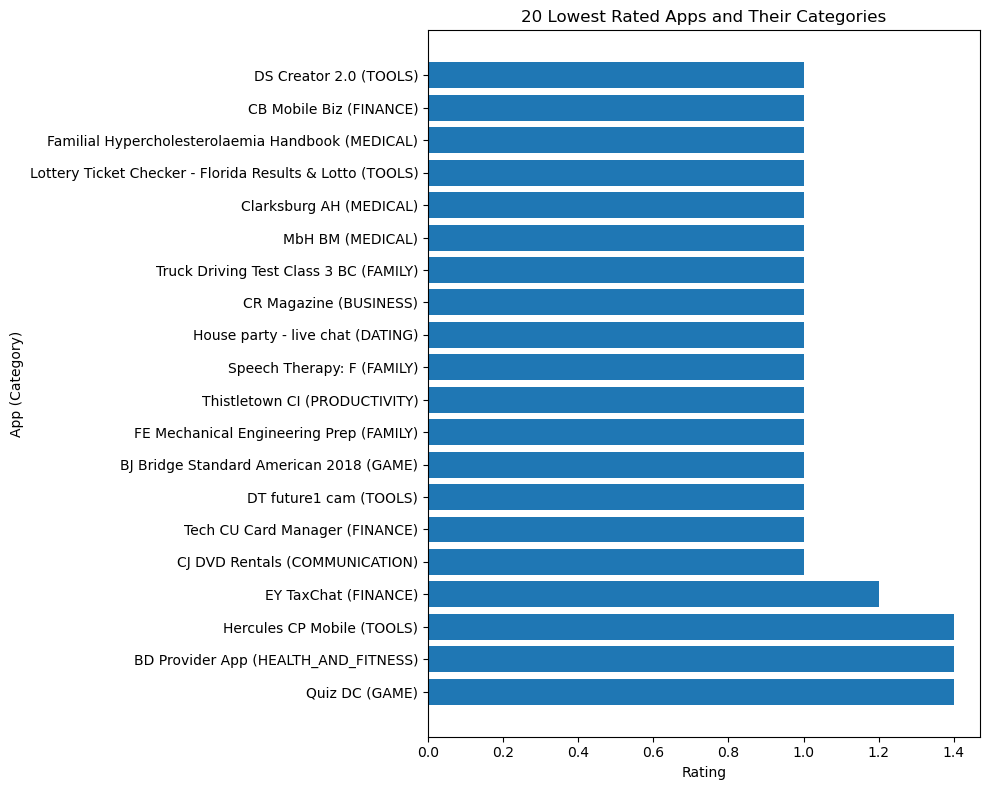

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("googleplaystore.csv")

# Clean ratings
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Keep rows with valid ratings
df_clean = df.dropna(subset=["Rating_clean"])

# Get 20 lowest-rated apps
lowest_rated_apps = (
    df_clean.sort_values("Rating_clean", ascending=True)
    [["App", "Category", "Rating_clean"]]
    .head(20)
)

# Create label combining app name and category
lowest_rated_apps["Label"] = (
    lowest_rated_apps["App"] + " (" + lowest_rated_apps["Category"] + ")"
)

# Plot
plt.figure(figsize=(10,8))

plt.barh(lowest_rated_apps["Label"], lowest_rated_apps["Rating_clean"])

plt.title("20 Lowest Rated Apps and Their Categories")
plt.xlabel("Rating")
plt.ylabel("App (Category)")

plt.gca().invert_yaxis()  # lowest rating at the top

plt.tight_layout()
plt.show()

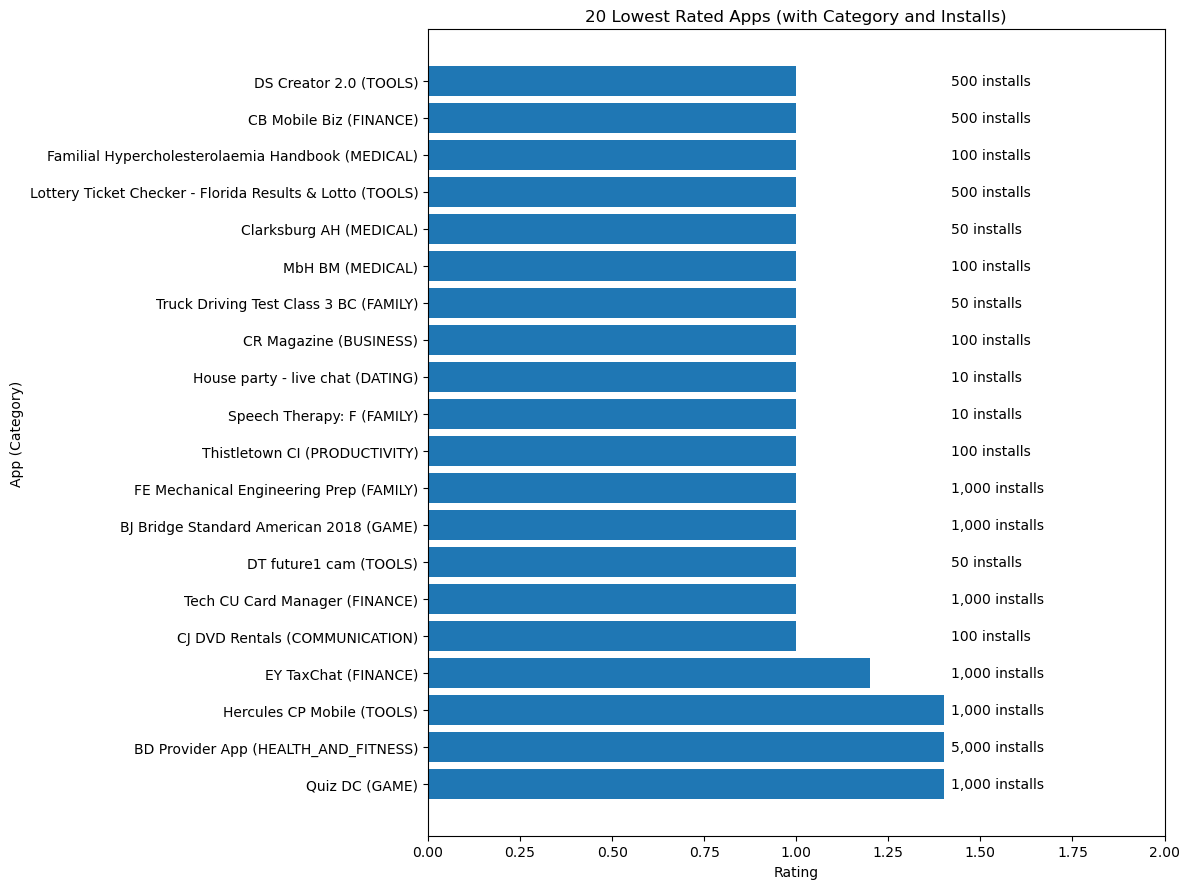

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("googleplaystore.csv")

# Clean Rating
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Clean Installs
df["Installs_clean"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# Keep rows with valid Rating + Installs
df_clean = df.dropna(subset=["Rating_clean", "Installs_clean", "App", "Category"]).copy()

# Get the 20 lowest-rated apps
lowest_rated = (
    df_clean.sort_values("Rating_clean", ascending=True)
    [["App", "Category", "Rating_clean", "Installs_clean"]]
    .head(20)
)

# Create a label: "App (Category)"
lowest_rated["Label"] = lowest_rated["App"] + " (" + lowest_rated["Category"] + ")"

# Plot rating as bars
plt.figure(figsize=(12, 9))
plt.barh(lowest_rated["Label"], lowest_rated["Rating_clean"])

plt.title("20 Lowest Rated Apps (with Category and Installs)")
plt.xlabel("Rating")
plt.ylabel("App (Category)")
plt.gca().invert_yaxis()  # lowest rating on top

# Annotate installs next to each bar
max_rating = lowest_rated["Rating_clean"].max()
for i, (rating, installs) in enumerate(zip(lowest_rated["Rating_clean"], lowest_rated["Installs_clean"])):
    plt.text(
        max_rating + 0.02,         # position text to the right of bars
        i,
        f"{int(installs):,} installs",
        va="center"
    )

# Give space on the right for the install labels
plt.xlim(0, max_rating + 0.6)

plt.tight_layout()
plt.show()

TypeError: text() missing 1 required positional argument: 's'

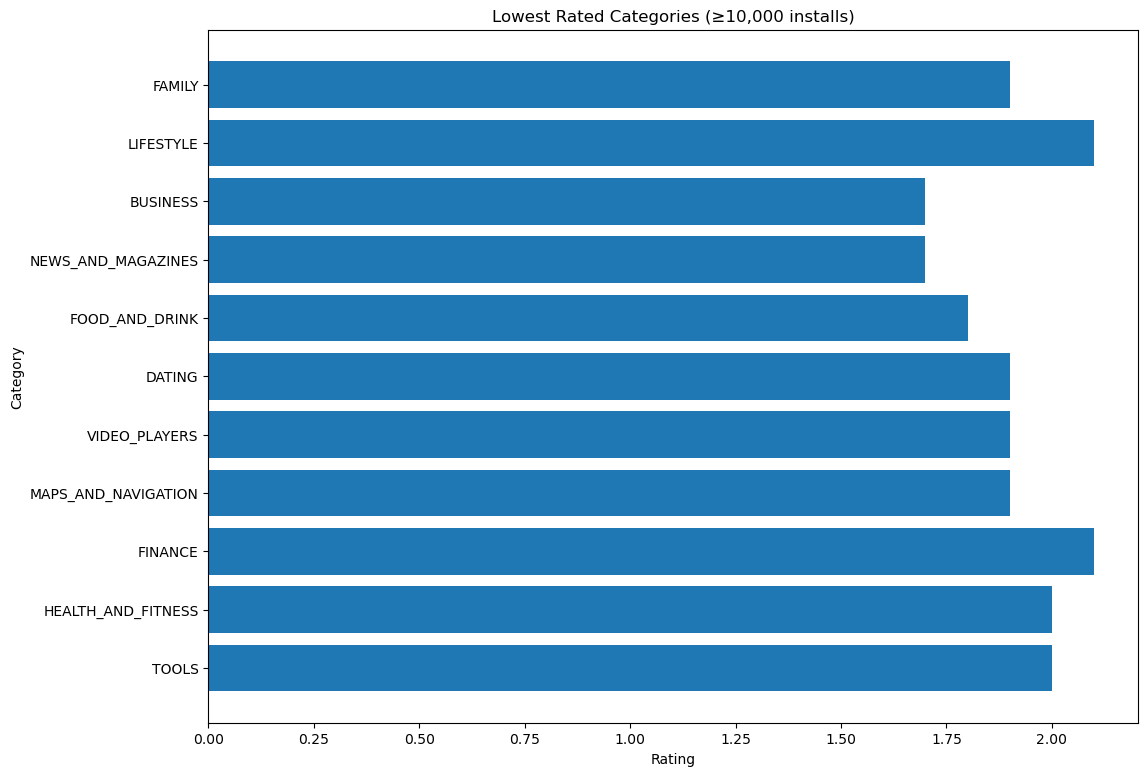

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("googleplaystore.csv")

# Clean ratings
df["Rating_clean"] = pd.to_numeric(df["Rating"], errors="coerce")

# Clean installs
df["Installs_clean"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
df["Installs_clean"] = pd.to_numeric(df["Installs_clean"], errors="coerce")

# Keep usable rows
df_clean = df.dropna(subset=["Rating_clean", "Installs_clean", "Category"]).copy()

# Filter apps with at least 10,000 installs
df_clean = df_clean[df_clean["Installs_clean"] >= 10000]

# Get 20 lowest rated apps
lowest_rated = (
    df_clean.sort_values("Rating_clean", ascending=True)
    [["Category", "Rating_clean", "Installs_clean"]]
    .head(20)
)

# Label for visualization
lowest_rated["Label"] = lowest_rated["Category"]

# Plot
plt.figure(figsize=(12,9))

plt.barh(lowest_rated["Label"], lowest_rated["Rating_clean"])

plt.title("Lowest Rated Categories (≥10,000 installs)")
plt.xlabel("Rating")
plt.ylabel("Category")

plt.gca().invert_yaxis()

# Add install numbers next to bars
max_rating = lowest_rated["Rating_clean"].max()

for i, (rating, installs) in enumerate(zip(lowest_rated["Rating_clean"], lowest_rated["Installs_clean"])):
    plt.text(
        i,
        f"{int(installs):,} installs",
        va="center"
    )

plt.xlim(0, max_rating + 0.6)

plt.tight_layout()
plt.show()